# 06 — Comparação de Modelos

Comparação de **4 modelos** com 15 features, walk-forward validation e otimização de hiperparâmetros.

| Modelo | Tipo |
|---|---|
| Regressão Logística | Linear, interpretável |
| Random Forest | Ensemble de árvores |
| XGBoost | Gradient Boosting |
| LightGBM | Gradient Boosting (eficiente) |

**Métrica principal:** AUC-ROC (mais adequada para classes desbalanceadas que acurácia).

## Pipeline de Dados (15 features)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, joblib, warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve, auc
from scipy.stats import loguniform

TARGET = 'Status_bin'
METRICAS = ['Pts', 'SG', 'Gols_Pro', 'Gols_Contra', 'V', 'Aproveitamento']
JANELAS  = [3, 5]
FEATURES_ELENCO = ['Plantel', 'Estrangeiros', 'Valor de Mercado Total']
FEATURES_JANELA = [f'{m}_media_{w}' for m in METRICAS for w in JANELAS]
FEATURES = FEATURES_ELENCO + FEATURES_JANELA

df = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()
df[TARGET] = df['Situacao'].apply(lambda x: 1 if str(x).strip().lower() == 'rebaixado' else 0)
df_desemp = pd.read_excel(os.path.join('..', 'dados', 'tabela_desempenho_brasileirao.xlsx'), sheet_name='Todos')
df_desemp.columns = df_desemp.columns.str.strip()
df_desemp = df_desemp.sort_values(['Clube', 'Temporada']).reset_index(drop=True)
for m in METRICAS:
    for w in JANELAS:
        df_desemp[f'{m}_media_{w}'] = (
            df_desemp.groupby('Clube')[m]
            .transform(lambda x: x.shift(1).rolling(window=w, min_periods=1).mean())
        )
COLS_MERGE = ['Clube', 'Temporada'] + FEATURES_JANELA
clubes_2025 = df['Clube'][df['Temporada'] == 2025].unique()
rows_2025 = []
for clube in clubes_2025:
    hist = df_desemp[df_desemp['Clube'] == clube].sort_values('Temporada', ascending=False)
    row  = {'Clube': clube, 'Temporada': 2025}
    for m in METRICAS:
        for w in JANELAS:
            ultimos = hist.head(w)[m]
            row[f'{m}_media_{w}'] = ultimos.mean() if len(ultimos) > 0 else None
    rows_2025.append(row)
df_ext = pd.concat([df_desemp[COLS_MERGE], pd.DataFrame(rows_2025)[COLS_MERGE]], ignore_index=True)
df = df.merge(df_ext[COLS_MERGE], on=['Clube', 'Temporada'], how='left')
df_rot = df[df['Temporada'] < 2025].copy()
df_tr  = df_rot[df_rot['Temporada'] <= 2022].copy()
df_te  = df_rot[df_rot['Temporada']  > 2022].copy()
mediana_treino = df_tr[FEATURES_JANELA].median()
for col in FEATURES_JANELA:
    df_tr[col] = df_tr[col].fillna(mediana_treino[col])
    df_te[col] = df_te[col].fillna(mediana_treino[col])
scaler = StandardScaler()
X_tr = scaler.fit_transform(df_tr[FEATURES]); y_tr = df_tr[TARGET].values
X_te = scaler.transform(df_te[FEATURES]);     y_te = df_te[TARGET].values
print(f'Treino: {X_tr.shape} | Teste: {X_te.shape} | Features: {len(FEATURES)}')

Treino: (180, 15) | Teste: (40, 15) | Features: 15


## Walk-Forward Validation — Todos os Modelos

Cada fold treina nos anos anteriores e valida no ano seguinte,
simulando como o modelo teria funcionado em produção ao longo do tempo.

In [2]:
# Walk-forward validation para todos os 4 modelos
temporadas_treino = sorted(df_tr['Temporada'].unique())
N_FOLDS = 5; inicio_val = len(temporadas_treino) - N_FOLDS

MODELOS_BASE = {
    'Regressao Logistica': LogisticRegression(C=1.0, random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                          scale_pos_weight=4, verbosity=0),
    'LightGBM':            LGBMClassifier(n_estimators=100, random_state=42,
                                           class_weight='balanced', verbose=-1),
}

wf_results = {nome: [] for nome in MODELOS_BASE}

for i in range(N_FOLDS):
    anos_tr = temporadas_treino[:inicio_val + i]
    ano_val = temporadas_treino[inicio_val + i]
    d_tr  = df_rot[df_rot['Temporada'].isin(anos_tr)].copy()
    d_val = df_rot[df_rot['Temporada'] == ano_val].copy()
    med = d_tr[FEATURES_JANELA].median()
    for col in FEATURES_JANELA:
        d_tr[col]  = d_tr[col].fillna(med[col])
        d_val[col] = d_val[col].fillna(med[col])
    sc = StandardScaler()
    Xf = sc.fit_transform(d_tr[FEATURES]); Xv = sc.transform(d_val[FEATURES])
    yf = d_tr[TARGET].values;              yv = d_val[TARGET].values
    print(f'Fold {i+1} | treino {anos_tr[0]}-{anos_tr[-1]} → val {ano_val}', end='  ')
    for nome, clf in MODELOS_BASE.items():
        clf.fit(Xf, yf)
        prob_v = clf.predict_proba(Xv)[:, 1]
        auc_v  = roc_auc_score(yv, prob_v) if yv.sum() > 0 else float('nan')
        wf_results[nome].append(auc_v)
    print(' | '.join(f'{n[:4]}: {wf_results[n][-1]:.3f}' for n in MODELOS_BASE))

print('\n=== AUC-ROC medio por modelo (walk-forward) ===')
for nome, aucs in wf_results.items():
    print(f'  {nome:<25} {np.nanmean(aucs):.3f} (+/- {np.nanstd(aucs):.3f})')

Fold 1 | treino 2014-2017 → val 2018  

  File "c:\Users\leona\Desktop\tcc\Previsao-Tcc\venv311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\leona\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\leona\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\leona\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Regr: 0.828 | Rand: 0.789 | XGBo: 0.766 | Ligh: 0.719
Fold 2 | treino 2014-2018 → val 2019  Regr: 0.859 | Rand: 0.734 | XGBo: 0.719 | Ligh: 0.750
Fold 3 | treino 2014-2019 → val 2020  Regr: 0.703 | Rand: 0.758 | XGBo: 0.531 | Ligh: 0.438
Fold 4 | treino 2014-2020 → val 2021  Regr: 0.750 | Rand: 0.656 | XGBo: 0.594 | Ligh: 0.688
Fold 5 | treino 2014-2021 → val 2022  Regr: 0.828 | Rand: 0.875 | XGBo: 0.688 | Ligh: 0.906

=== AUC-ROC medio por modelo (walk-forward) ===
  Regressao Logistica       0.794 (+/- 0.058)
  Random Forest             0.762 (+/- 0.071)
  XGBoost                   0.659 (+/- 0.085)
  LightGBM                  0.700 (+/- 0.151)


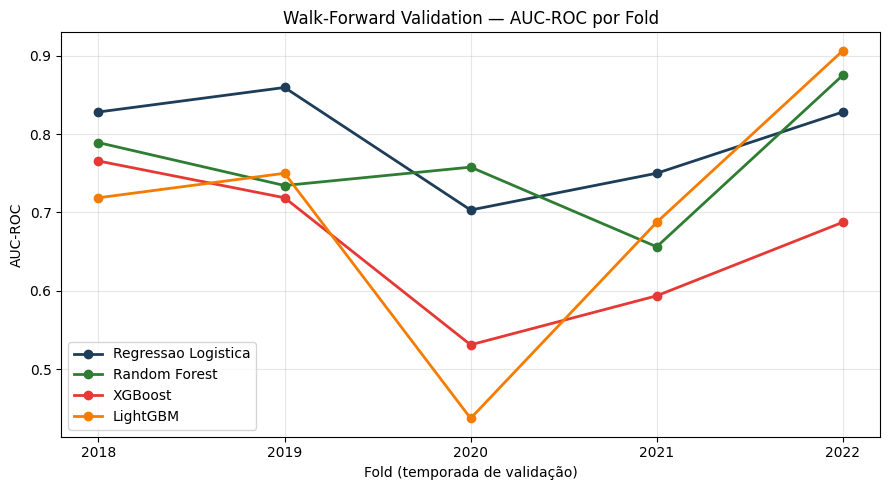

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(1, N_FOLDS + 1)
cores_list = ['#1e3d59', '#2e7d32', '#e53935', '#f57c00']
for (nome, aucs), cor in zip(wf_results.items(), cores_list):
    ax.plot(x, aucs, marker='o', lw=2, color=cor, label=nome)
ax.set_xlabel('Fold (temporada de validação)')
ax.set_ylabel('AUC-ROC')
ax.set_title('Walk-Forward Validation — AUC-ROC por Fold')
ax.set_xticks(list(x))
ax.set_xticklabels([str(temporadas_treino[inicio_val + i]) for i in range(N_FOLDS)])
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Otimização de Hiperparâmetros (RandomizedSearchCV + TimeSeriesSplit)

50 candidatos aleatórios por modelo, avaliados com TimeSeriesSplit(5 folds) e AUC-ROC.

In [4]:
tscv = TimeSeriesSplit(n_splits=5)

grids = {
    'Regressao Logistica': (
        LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
        {'C': loguniform(0.001, 100), 'solver': ['lbfgs', 'liblinear']}
    ),
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced', random_state=42),
        {'n_estimators': [50,100,200,300], 'max_depth': [None,3,5,7],
         'min_samples_split': [2,5,10], 'max_features': ['sqrt','log2']}
    ),
    'XGBoost': (
        XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=4, verbosity=0),
        {'n_estimators': [50,100,200], 'max_depth': [3,5,7],
         'learning_rate': [0.01,0.05,0.1,0.2], 'subsample': [0.7,0.8,1.0]}
    ),
    'LightGBM': (
        LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1),
        {'n_estimators': [50,100,200], 'max_depth': [3,5,7,-1],
         'learning_rate': [0.01,0.05,0.1,0.2], 'num_leaves': [15,31,63]}
    ),
}

melhores = {}
for nome, (clf_base, param_dist) in grids.items():
    search = RandomizedSearchCV(clf_base, param_distributions=param_dist,
                                 n_iter=30, scoring='roc_auc', cv=tscv,
                                 random_state=42, n_jobs=1)
    search.fit(X_tr, y_tr)
    melhores[nome] = search.best_estimator_
    print(f'{nome:<25} best AUC-CV={search.best_score_:.3f} | params={search.best_params_}')

Regressao Logistica       best AUC-CV=0.754 | params={'C': 0.9846738873614566, 'solver': 'lbfgs'}
Random Forest             best AUC-CV=0.760 | params={'n_estimators': 100, 'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 3}
XGBoost                   best AUC-CV=0.742 | params={'subsample': 0.7, 'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.05}
LightGBM                  best AUC-CV=0.721 | params={'num_leaves': 31, 'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.01}


## Avaliação Final no Conjunto de Teste (2023–2024)

In [5]:
resultados = []
for nome, clf in melhores.items():
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]
    resultados.append({
        'Modelo':    nome,
        'Acuracia':  round(accuracy_score(y_te, y_pred), 3),
        'AUC-ROC':   round(roc_auc_score(y_te, y_prob), 3),
    })

df_res = pd.DataFrame(resultados).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
df_res.index += 1
print('=== Comparacao Final (conjunto de teste 2023-2024) ===')
print(df_res.to_string(index=True))
print(f'\nMelhor modelo por AUC-ROC: {df_res.iloc[0]["Modelo"]}')

=== Comparacao Final (conjunto de teste 2023-2024) ===
                Modelo  Acuracia  AUC-ROC
1             LightGBM     0.825    0.877
2        Random Forest     0.800    0.844
3  Regressao Logistica     0.800    0.828
4              XGBoost     0.825    0.652

Melhor modelo por AUC-ROC: LightGBM


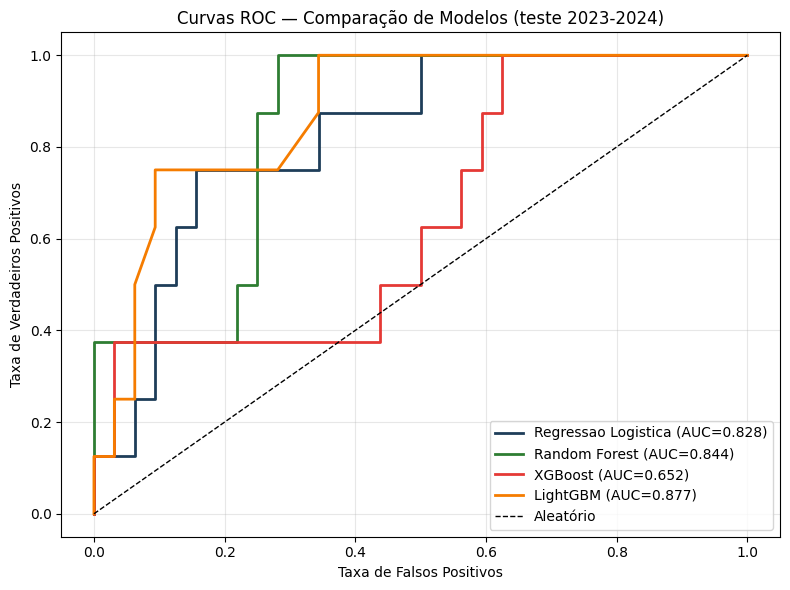

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
cores = {'Regressao Logistica': '#1e3d59', 'Random Forest': '#2e7d32',
         'XGBoost': '#e53935', 'LightGBM': '#f57c00'}
for nome, clf in melhores.items():
    y_prob = clf.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=cores.get(nome, 'gray'),
            label=f'{nome} (AUC={roc_auc_val:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Aleatório')
ax.set_xlabel('Taxa de Falsos Positivos'); ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curvas ROC — Comparação de Modelos (teste 2023-2024)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Justificativa do Modelo Final

A tabela acima ordena os modelos por **AUC-ROC** — a métrica principal escolhida por ser mais robusta
a desbalanceamento de classes (80 % permanece vs. 20 % rebaixado).

**Critérios de escolha:**
- AUC-ROC mais alto no conjunto de teste independente
- AUC-ROC estável ao longo dos folds de walk-forward (baixo desvio padrão)
- Interpretabilidade: preferência por modelos cujos resultados podem ser explicados ao professor e banca

A **Regressão Logística** mantém vantagem em interpretabilidade (coeficientes diretos), enquanto
**XGBoost/LightGBM** tendem a ter AUC mais alto em datasets com features não-lineares.
O modelo com melhor AUC no teste é escolhido como modelo final para a previsão de 2025.

In [7]:
os.makedirs(os.path.join('..', 'modelos'), exist_ok=True)
for nome, clf in melhores.items():
    fname = nome.lower().replace(' ', '_').replace('ã', 'a').replace('ç', 'c') + '.pkl'
    joblib.dump(clf, os.path.join('..', 'modelos', fname))
    print(f'Salvo: {fname}')
joblib.dump(scaler, os.path.join('..', 'modelos', 'scaler_logistica.pkl'))
joblib.dump(mediana_treino, os.path.join('..', 'modelos', 'mediana_treino.pkl'))
print('Scaler e mediana salvos.')

Salvo: regressao_logistica.pkl
Salvo: random_forest.pkl
Salvo: xgboost.pkl
Salvo: lightgbm.pkl
Scaler e mediana salvos.
